# ESS Battery Health 

데이터셋 : Stanford & MIT - *Data-driven prediction of battery cycle life before capacity degradation* (Nature Energy, 2019)  

In [1]:
#!pip install mat73 h5py


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [2]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser(
    'D:\ess-battery-project\dataset'
)

files = sorted(os.listdir(DATA_DIR))
print(f"데이터 경로 : {DATA_DIR}")
print(f"파일 목록 :")
for f in files:
    size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
    print(f"   {f}  ({size_mb:.1f} GB)")

데이터 경로 : D:\ess-battery-project\dataset
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## Loading

In [3]:
# Batch 3 로드
batch3_path = os.path.join(DATA_DIR, '2018-04-12_batchdata_updated_struct_errorcorrect.mat')
def load_mat(path):
    """
    .mat 파일 로더 (버전 자동 감지)
    - MATLAB v7.3 (HDF5, 대용량) : mat73.loadmat() 사용
    - MATLAB v7.2 이하          : scipy.io.loadmat() 사용
    """
    try:
        data = mat73.loadmat(path)
        print("로드 완료 (MATLAB v7.3 / HDF5 형식)")
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
        print("로드 완료 (MATLAB v7.2 이하 형식)")
    return data

print("로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)")
mat = load_mat(batch3_path)

# 최상위 키 확인
print(f"\n최상위 키 : {list(mat.keys())}")

ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... (파일이 크므로 수십 초 소요될 수 있습니다)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)


로드 완료 (MATLAB v7.3 / HDF5 형식)

최상위 키 : ['batch', 'batch_date']


## 데이터 타입 및 구조 확인

In [5]:
batch = mat['batch']

# mat73은 list of dict, scipy는 structured array로 반환
# 아래 코드로 둘 다 동일하게 처리
if isinstance(batch, dict):
    # mat73: {'field': [val0, val1, ...]} 형태 → list of dict로 변환
    keys = list(batch.keys())
    n_cells = len(batch[keys[0]])
    batch = [{k: batch[k][i] for k in keys} for i in range(n_cells)]
    print("mat73 형식 → list of dict 변환 완료")

print(f"배터리 셀 수    : {len(batch)}")
print(f"타입            : {type(batch)}")
print(f"첫 번째 셀 키   : {list(batch[0].keys())}")

mat73 형식 → list of dict 변환 완료
배터리 셀 수    : 46
타입            : <class 'list'>
첫 번째 셀 키   : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary']


In [6]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 5C_67PER_4C_NEWSTRUCTURE
  policy_readable           | str      | 5C(67%)-4C-newstructure
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']


In [7]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1008

사이클[0] 내 변수 목록 :
  I               | ndarray | shape=(762,) | dtype=float64
  Qc              | ndarray | shape=(762,) | dtype=float64
  Qd              | ndarray | shape=(762,) | dtype=float64
  Qdlin           | ndarray | shape=(1000,) | dtype=float64
  T               | ndarray | shape=(762,) | dtype=float64
  Tdlin           | ndarray | shape=(1000,) | dtype=float64
  V               | ndarray | shape=(762,) | dtype=float64
  discharge_dQdV  | ndarray | shape=(1000,) | dtype=float64
  t               | ndarray | shape=(762,) | dtype=float64


In [8]:
import numpy as np
import pandas as pd

def safe_scalar(x):
    # MATLAB scalar를 파이썬 scalar로 변환
    if isinstance(x, np.ndarray):
        if x.size == 0:
            return np.nan
        if x.size == 1:
            return x.item()
    return x

def safe_int(x):
    # 결측이면 np.nan 반환, 아니면 int 변환
    x = safe_scalar(x)
    if x is None:
        return np.nan
    try:
        if pd.isna(x):
            return np.nan
        return int(x)
    except:
        return np.nan

def safe_str(x, default='unknown'):
    # 문자열 결측 처리
    x = safe_scalar(x)
    if x is None:
        return default
    try:
        if pd.isna(x):
            return default
    except:
        pass
    return str(x)

def extract_summary(batch):
    rows = []

    for i, cell in enumerate(batch):
        summary = cell.get('summary', {})
        if not isinstance(summary, dict):
            continue

        cycle = np.asarray(summary.get('cycle', []))
        qd    = np.asarray(summary.get('QDischarge', []))
        qc    = np.asarray(summary.get('QCharge', []))
        ir    = np.asarray(summary.get('IR', []))
        tavg  = np.asarray(summary.get('Tavg', []))
        tmax  = np.asarray(summary.get('Tmax', []))
        tmin  = np.asarray(summary.get('Tmin', []))
        ct    = np.asarray(summary.get('chargetime', []))

        cycle_life = safe_int(cell.get('cycle_life'))
        policy = safe_str(cell.get('policy_readable')) \
                 if cell.get('policy_readable') is not None \
                 else safe_str(cell.get('policy'))

        n = min(len(cycle), len(qd), len(qc), len(ir), len(tavg), len(tmax), len(tmin), len(ct))

        for j in range(n):
            rows.append({
                'cell_id': i,
                'cycle': cycle[j],
                'cycle_life': cycle_life,
                'QD': qd[j],
                'QC': qc[j],
                'IR': ir[j],
                'Tmax': tmax[j],
                'Tavg': tavg[j],
                'Tmin': tmin[j],
                'chargetime': ct[j],
                'charging_policy': policy
            })

    return pd.DataFrame(rows)

In [9]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

DataFrame shape : (51007, 11)


,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime,charging_policy
0,0,1.0,1009.0,1.066573,1.066090,0.015435,33.433834,32.149495,30.830272,10.043408,5C(67%)-4C-newstructure
1,0,2.0,1009.0,1.067455,1.066964,0.015399,33.403964,32.106606,30.779943,10.043255,5C(67%)-4C-newstructure
2,0,3.0,1009.0,1.068285,1.067611,0.015365,33.325268,32.088511,30.824746,10.042333,5C(67%)-4C-newstructure
3,0,4.0,1009.0,1.068708,1.068164,0.015326,33.304202,32.086306,30.804544,10.052677,5C(67%)-4C-newstructure
4,0,5.0,1009.0,1.069094,1.068695,0.015309,33.257191,32.041147,30.791834,10.042382,5C(67%)-4C-newstructure


In [10]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,51007.000,51007.000,46581.000,51007.000,51007.000,51007.000,51007.000,51007.000,51007.000,51007.000
mean,23.331,621.448,1150.600,1.028,1.028,0.016,38.529,35.500,32.598,10.470
std,13.473,442.300,349.576,0.043,0.042,0.001,2.402,1.692,1.023,0.711
min,0.000,1.000,541.000,0.880,0.880,0.010,31.209,31.003,28.032,10.024
25%,12.000,278.000,858.000,1.014,1.014,0.015,36.899,34.183,31.863,10.043
50%,23.000,555.000,1048.000,1.042,1.042,0.015,38.916,35.565,32.491,10.054
75%,35.000,855.000,1284.000,1.059,1.058,0.016,40.194,36.769,33.365,11.038
max,45.000,2237.000,1935.000,1.100,1.103,0.021,44.663,41.440,36.691,24.003


In [11]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 8


결측치 처리

In [12]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id               0
cycle                 0
cycle_life         4426
QD                    0
QC                    0
IR                    0
Tmax                  0
Tavg                  0
Tmin                  0
chargetime            0
charging_policy       0
dtype: int64


In [15]:
df = df.dropna(subset=["cycle_life"])

In [16]:
df.isnull().sum()

cell_id            0
cycle              0
cycle_life         0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
charging_policy    0
dtype: int64

## EDA

### 1. Cycle Life 분포

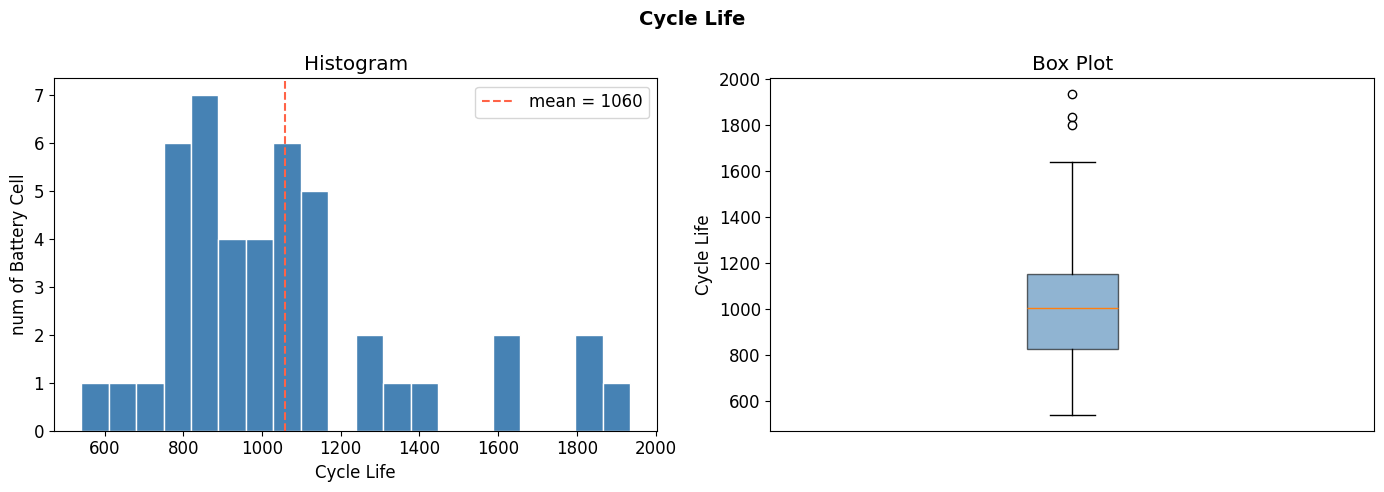

count      44.0
mean     1059.7
std       313.9
min       541.0
25%       828.0
50%      1005.5
75%      1155.2
max      1935.0
Name: cycle_life, dtype: float64


In [17]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

In [27]:
cell_df = df.groupby("cell_id", as_index=False)["cycle_life"].max()

long_count = (cell_df["cycle_life"] > 1000).sum()
short_count = (cell_df["cycle_life"] < 500).sum()
total = len(cell_df)

print(f"장수명(>1000): {long_count} / {total} ({long_count/total:.2%})")
print(f"단수명(<500): {short_count} / {total} ({short_count/total:.2%})")

장수명(>1000): 23 / 44 (52.27%)
단수명(<500): 0 / 44 (0.00%)


### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

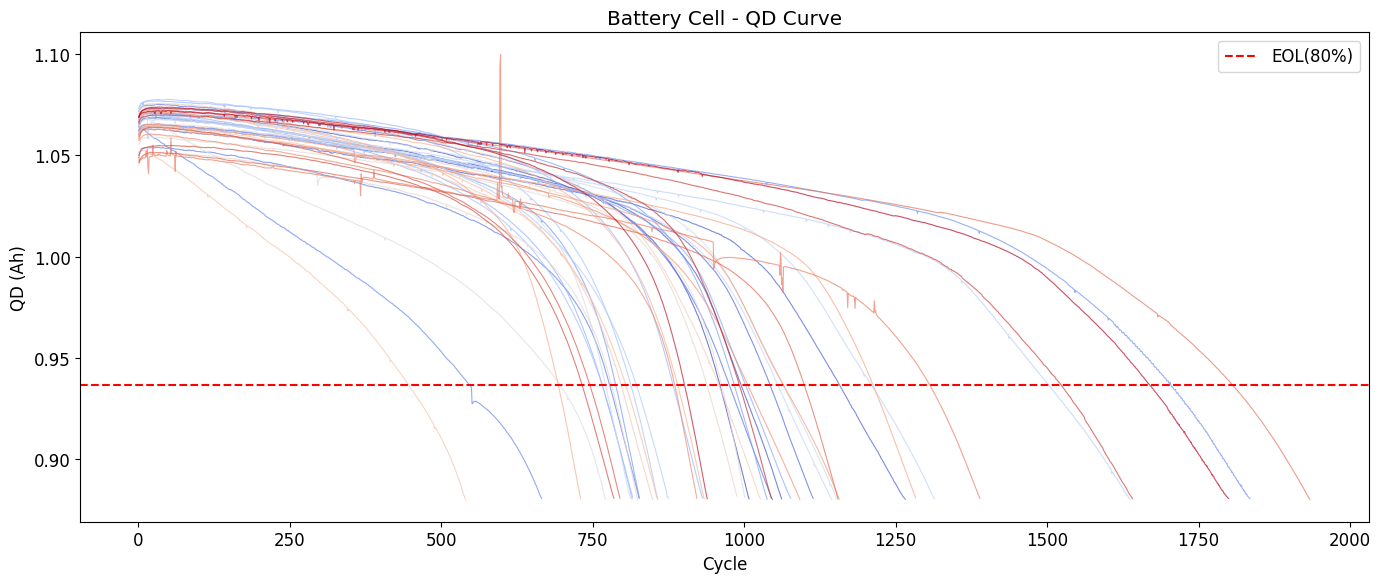

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 구간별 선형 기울기 계산
def calc_slope(data, start_cycle, end_cycle):
    d = data[(data["cycle"] >= start_cycle) & (data["cycle"] <= end_cycle)].copy()
    d = d.dropna(subset=["cycle", "QD"])
    
    if len(d) < 2:
        return np.nan
    
    x = d["cycle"].values
    y = d["QD"].values
    
    slope = np.polyfit(x, y, 1)[0]
    return slope

# cell별 초기/중기/후기 열화 속도 계산
def get_degradation_slopes(cell_df):
    cell_df = cell_df.sort_values("cycle")
    
    return pd.Series({
        "slope_early": calc_slope(cell_df, 1, 100),
        "slope_mid": calc_slope(cell_df, 101, 300),
        "slope_late": calc_slope(cell_df, 301, 600),
    })

slope_df = df.groupby("cell_id").apply(get_degradation_slopes).reset_index()

policy_map = df.groupby("cell_id", as_index=False)["charging_policy"].first()
slope_df = slope_df.merge(policy_map, on="cell_id", how="left")

# 정책별 평균 slope 표
policy_slope_df = (
    slope_df.groupby("charging_policy", as_index=False)[["slope_early", "slope_mid", "slope_late"]]
    .mean()
)

# 열화 가속 여부 판단용 컬럼
policy_slope_df["acceleration"] = policy_slope_df["slope_late"] - policy_slope_df["slope_early"]

print("정책별 열화 속도 표")
print(policy_slope_df.round(6))

정책별 열화 속도 표
               charging_policy  slope_early  slope_mid  slope_late  \
0  3.7C(31%)-5.9C-newstructure    -0.000185  -0.000197   -0.000295   
1  4.8C(80%)-4.8C-newstructure    -0.000001  -0.000031   -0.000038   
2    5.3C(54%)-4C-newstructure    -0.000003  -0.000036   -0.000053   
3  5.6C(19%)-4.6C-newstructure    -0.000012  -0.000045   -0.000079   
4  5.6C(36%)-4.3C-newstructure    -0.000007  -0.000041   -0.000078   
5  5.9C(15%)-4.6C-newstructure    -0.000001  -0.000047   -0.000101   
6  5.9C(60%)-3.1C-newstructure    -0.000010  -0.000038   -0.000092   
7      5C(67%)-4C-newstructure    -0.000001  -0.000038   -0.000065   

   acceleration  
0     -0.000110  
1     -0.000037  
2     -0.000051  
3     -0.000067  
4     -0.000071  
5     -0.000100  
6     -0.000082  
7     -0.000063  


<Figure size 1400x600 with 0 Axes>

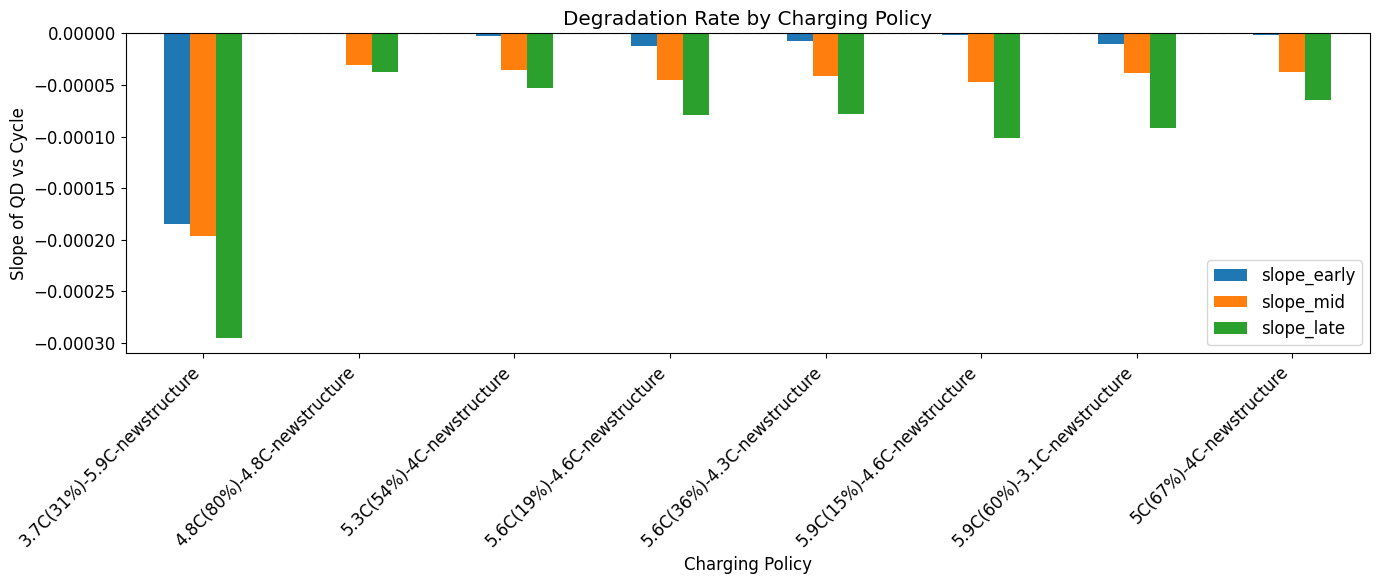

In [29]:
plot_df = policy_slope_df.set_index("charging_policy")[["slope_early", "slope_mid", "slope_late"]]

plt.figure(figsize=(14, 6))
plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Degradation Rate by Charging Policy")
plt.xlabel("Charging Policy")
plt.ylabel("Slope of QD vs Cycle")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, linestyle="--")
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import pandas as pd

def find_knee_point_v2(cell_df, smooth_window=20, skip_first=100):
    d = cell_df.sort_values("cycle")[["cycle", "QD"]].dropna().copy()

    if len(d) < smooth_window + 10:
        return pd.Series({
            "knee_cycle": np.nan,
            "knee_qd": np.nan
        })

    # QD smoothing
    d["QD_smooth"] = d["QD"].rolling(window=smooth_window, center=True, min_periods=1).mean()

    # 1차 차분: 기울기 근사
    d["slope"] = np.gradient(d["QD_smooth"], d["cycle"])

    # 2차 차분: 기울기 변화량
    d["slope_change"] = np.gradient(d["slope"], d["cycle"])

    # 초반 noise 제외
    d_valid = d[d["cycle"] >= skip_first].copy()

    if d_valid["slope_change"].dropna().empty:
        return pd.Series({
            "knee_cycle": np.nan,
            "knee_qd": np.nan
        })

    # 가장 급격히 꺾이는 지점
    knee_idx = d_valid["slope_change"].idxmin()
    knee_cycle = d.loc[knee_idx, "cycle"]
    knee_qd = d.loc[knee_idx, "QD"]

    return pd.Series({
        "knee_cycle": knee_cycle,
        "knee_qd": knee_qd
    })

In [31]:
knee_df = df.groupby("cell_id").apply(find_knee_point_v2).reset_index()
print(knee_df.head())
print(knee_df["knee_cycle"].describe())
print(knee_df["knee_cycle"].nunique())

   cell_id  knee_cycle   knee_qd
0        0       937.0  0.959642
1        1       574.0  1.043929
2        2       500.0  1.043655
3        3       962.0  0.988250
4        4       884.0  0.993843
count      44.000000
mean      684.795455
std       319.399624
min       125.000000
25%       444.750000
50%       684.000000
75%       884.750000
max      1673.000000
Name: knee_cycle, dtype: float64
44


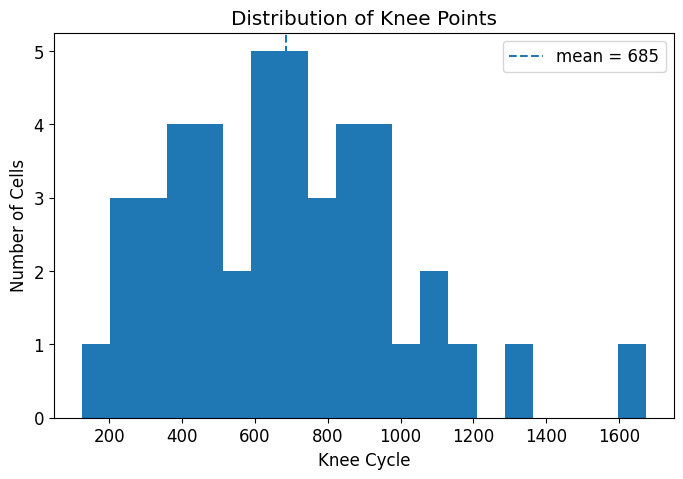

In [32]:
import matplotlib.pyplot as plt

# NaN 제거
knee_valid = knee_df.dropna(subset=["knee_cycle"])

plt.figure(figsize=(8,5))
plt.hist(knee_valid["knee_cycle"], bins=20)
plt.xlabel("Knee Cycle")
plt.ylabel("Number of Cells")
plt.title("Distribution of Knee Points")
plt.axvline(knee_valid["knee_cycle"].mean(), linestyle="--",
            label=f"mean = {knee_valid['knee_cycle'].mean():.0f}")
plt.legend()
plt.show()

### 3. ΔQ(V) 곡선 분석

Q1(하위 25%) 기준 : 828.00
Q3(상위 25%) 기준 : 1155.25
Long cells 수     : 11
Short cells 수    : 12


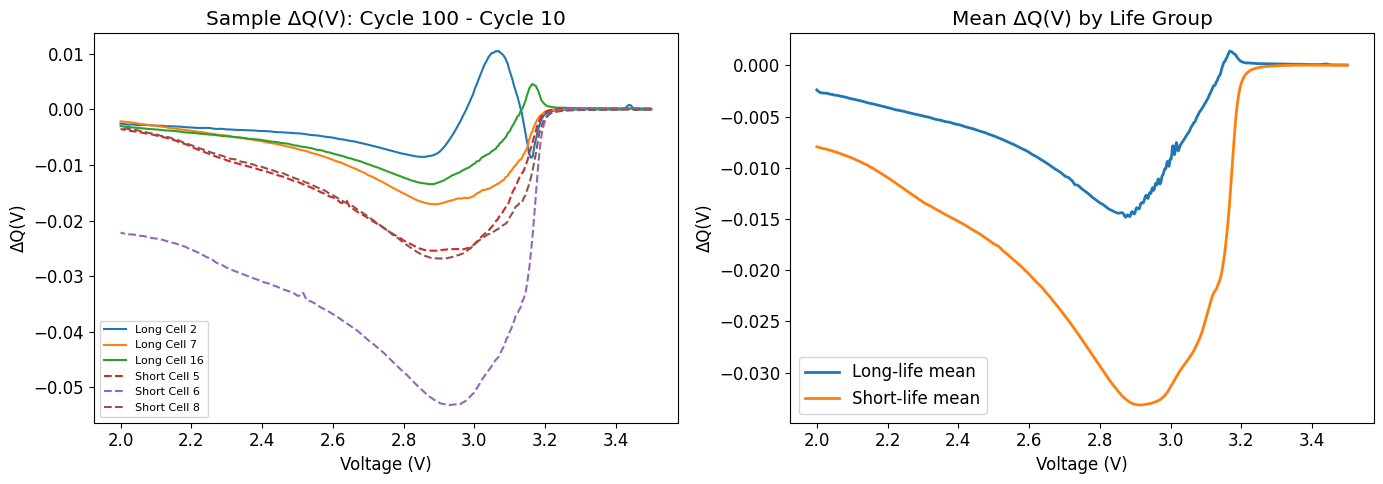

,cell_id,delta_mean,delta_std,delta_min,delta_max,delta_range,delta_area,cycle_life
0,0,-0.010102,0.007541,-0.023312,0.000042,0.023354,0.015166,1009.0
1,1,-0.009621,0.007198,-0.022324,-0.000152,0.022172,0.014443,1063.0
2,2,-0.002613,0.004077,-0.008648,0.010524,0.019172,0.003922,1267.0
3,3,-0.010705,0.008744,-0.026837,0.000073,0.026909,0.016071,1115.0
4,4,-0.010106,0.008143,-0.024810,-0.000049,0.024761,0.015172,1048.0


,cycle_life
cycle_life,1.000000
delta_min,0.692116
delta_mean,0.639115
delta_max,0.407698
delta_range,-0.601037
delta_area,-0.639173
delta_std,-0.672606


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# cell_id별 대표 cycle_life
cycle_life_df = df.groupby("cell_id", as_index=False)["cycle_life"].max()

q25 = cycle_life_df["cycle_life"].quantile(0.25)
q75 = cycle_life_df["cycle_life"].quantile(0.75)

long_cells = cycle_life_df[cycle_life_df["cycle_life"] >= q75]["cell_id"].tolist()
short_cells = cycle_life_df[cycle_life_df["cycle_life"] <= q25]["cell_id"].tolist()

print(f"Q1(하위 25%) 기준 : {q25:.2f}")
print(f"Q3(상위 25%) 기준 : {q75:.2f}")
print(f"Long cells 수     : {len(long_cells)}")
print(f"Short cells 수    : {len(short_cells)}")

def get_cycles_list(cell):
    cycles_list = cell["cycles"]
    if isinstance(cycles_list, dict):
        keys = list(cycles_list.keys())
        n = len(cycles_list[keys[0]])
        cycles_list = [{k: cycles_list[k][i] for k in keys} for i in range(n)]
    return cycles_list

def get_delta_qv(cell, cycle_a=10, cycle_b=100):
    cycles_list = get_cycles_list(cell)

    if len(cycles_list) < cycle_b:
        return None, None

    ca = cycles_list[cycle_a - 1]
    cb = cycles_list[cycle_b - 1]

    q_a = np.array(ca["Qdlin"]).flatten()
    q_b = np.array(cb["Qdlin"]).flatten()

    # 공통 전압축: cell-level Vdlin 사용
    v = np.array(cell["Vdlin"]).flatten()

    min_len = min(len(v), len(q_a), len(q_b))
    if min_len == 0:
        return None, None

    v = v[:min_len]
    delta = q_b[:min_len] - q_a[:min_len]
    return v, delta

# 1. 샘플 셀 ΔQ(V) 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cid in long_cells[:3]:
    v, delta = get_delta_qv(batch[cid], 10, 100)
    if v is not None:
        axes[0].plot(v, delta, label=f"Long Cell {cid}", linewidth=1.5)

for cid in short_cells[:3]:
    v, delta = get_delta_qv(batch[cid], 10, 100)
    if v is not None:
        axes[0].plot(v, delta, "--", label=f"Short Cell {cid}", linewidth=1.5)

axes[0].set_xlabel("Voltage (V)")
axes[0].set_ylabel("ΔQ(V)")
axes[0].set_title("Sample ΔQ(V): Cycle 100 - Cycle 10")
axes[0].legend(fontsize=8)

# 2. 그룹 평균 ΔQ(V)
long_curves = []
short_curves = []
v_ref = None

for cid in long_cells:
    v, delta = get_delta_qv(batch[cid], 10, 100)
    if v is not None:
        long_curves.append(delta)
        v_ref = v

for cid in short_cells:
    v, delta = get_delta_qv(batch[cid], 10, 100)
    if v is not None:
        short_curves.append(delta)

long_arr = np.vstack(long_curves)
short_arr = np.vstack(short_curves)

axes[1].plot(v_ref, long_arr.mean(axis=0), label="Long-life mean", linewidth=2)
axes[1].plot(v_ref, short_arr.mean(axis=0), label="Short-life mean", linewidth=2)
axes[1].set_xlabel("Voltage (V)")
axes[1].set_ylabel("ΔQ(V)")
axes[1].set_title("Mean ΔQ(V) by Life Group")
axes[1].legend()

plt.tight_layout()
plt.show()

# 3. 통계 피처 후보 추출
features = []

for cid in cycle_life_df["cell_id"]:
    v, delta = get_delta_qv(batch[cid], 10, 100)
    if v is None:
        continue

    delta_area = float(np.trapezoid(delta, v)) if hasattr(np, "trapezoid") else np.nan

    features.append({
        "cell_id": cid,
        "delta_mean": float(np.mean(delta)),
        "delta_std": float(np.std(delta)),
        "delta_min": float(np.min(delta)),
        "delta_max": float(np.max(delta)),
        "delta_range": float(np.max(delta) - np.min(delta)),
        "delta_area": delta_area,
    })

delta_feature_df = pd.DataFrame(features).merge(cycle_life_df, on="cell_id", how="left")

display(delta_feature_df.head())

feature_cols = ["delta_mean", "delta_std", "delta_min", "delta_max", "delta_range", "delta_area"]

corr_df = delta_feature_df[feature_cols + ["cycle_life"]].corr()[["cycle_life"]].sort_values("cycle_life", ascending=False)
display(corr_df)

### 4. 충전 정책(C-rate)과 수명의 관계

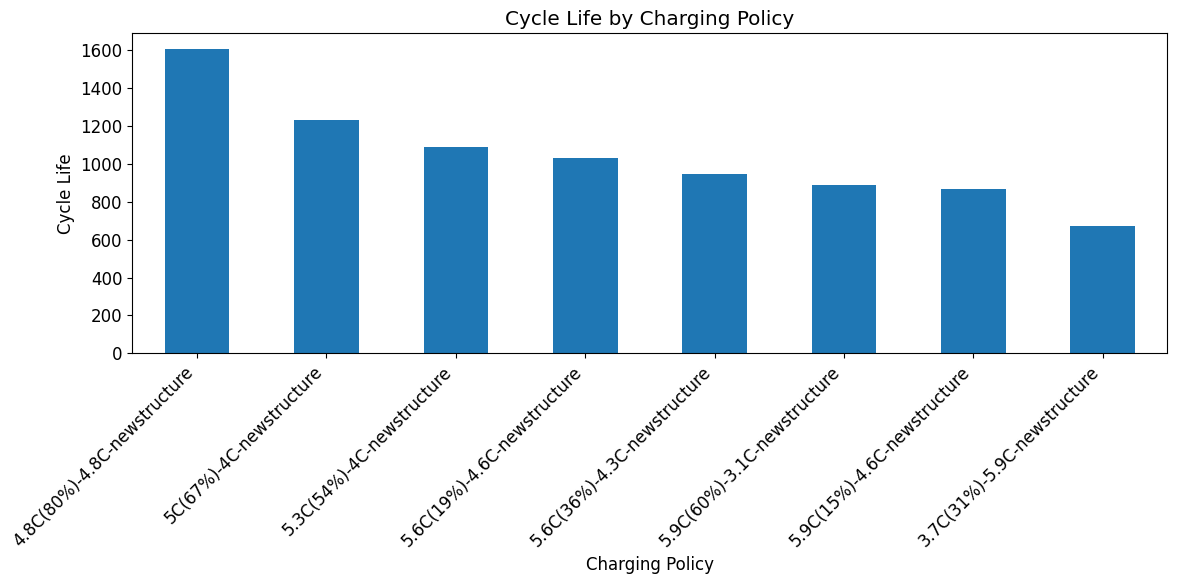

In [22]:
data=df.groupby("charging_policy")["cycle_life"].mean().sort_values(ascending=False)
plt.figure(figsize=(12,6))
data.plot(kind="bar")

plt.ylabel("Cycle Life")
plt.xlabel("Charging Policy")
plt.title("Cycle Life by Charging Policy")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

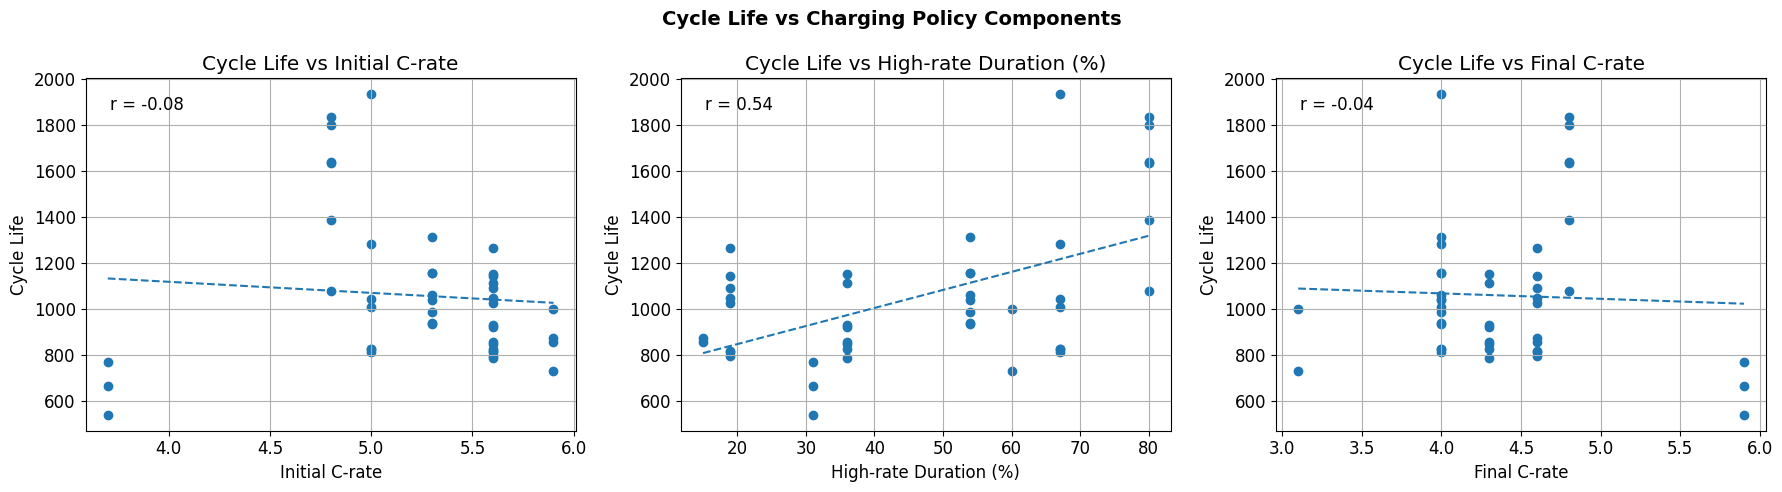

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# cell 단위 데이터
df_cell = df.drop_duplicates("cell_id")[["cell_id", "cycle_life", "charging_policy"]].copy()

# policy에서 3개 요소 추출
df_cell["C_rate_1"] = df_cell["charging_policy"].str.extract(r'(\d+\.?\d*)C').astype(float)
df_cell["ratio"] = df_cell["charging_policy"].str.extract(r'\((\d+)%\)').astype(float)
df_cell["C_rate_2"] = df_cell["charging_policy"].str.extract(r'-([0-9\.]+)C').astype(float)

# 1행 3열 figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

features = ["C_rate_1", "ratio", "C_rate_2"]
titles = ["Cycle Life vs Initial C-rate",
          "Cycle Life vs High-rate Duration (%)",
          "Cycle Life vs Final C-rate"]
xlabels = ["Initial C-rate", "High-rate Duration (%)", "Final C-rate"]

for ax, feature, title, xlabel in zip(axes, features, titles, xlabels):
    x = df_cell[feature].values
    y = df_cell["cycle_life"].values

    # 산점도
    ax.scatter(x, y)

    # 추세선
    coef = np.polyfit(x, y, 1)
    trend = np.poly1d(coef)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, trend(x_line), linestyle="--")

    # 상관계수 표시
    corr = np.corrcoef(x, y)[0, 1]

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Cycle Life")
    ax.grid(True)
    ax.text(0.05, 0.95, f"r = {corr:.2f}",
            transform=ax.transAxes,
            verticalalignment="top")

plt.suptitle("Cycle Life vs Charging Policy Components", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [34]:
# cell 단위 데이터
df_cell = df.drop_duplicates("cell_id")[["cell_id", "cycle_life", "charging_policy"]].copy()

# 충전 패턴
df_cell["C_rate_1"] = df_cell["charging_policy"].str.extract(r'(\d+\.?\d*)C').astype(float)
df_cell["ratio"] = df_cell["charging_policy"].str.extract(r'\((\d+)%\)').astype(float)
df_cell["C_rate_2"] = df_cell["charging_policy"].str.extract(r'-([0-9\.]+)C').astype(float)

df_cell["effective_C"] = df_cell["C_rate_1"] * df_cell["ratio"] / 100

# slope 데이터 (이미 만든 거 있다고 가정)
df_final = df_cell.merge(slope_df, on="cell_id")

In [35]:
corr = df_final[[
    "C_rate_1", "ratio", "C_rate_2", "effective_C",
    "slope_early", "slope_mid", "slope_late"
]].corr()

print(corr.round(2))

             C_rate_1  ratio  C_rate_2  effective_C  slope_early  slope_mid  \
C_rate_1         1.00  -0.36     -0.66        -0.20         0.72       0.69   
ratio           -0.36   1.00     -0.29         0.98         0.26       0.30   
C_rate_2        -0.66  -0.29      1.00        -0.45        -0.71      -0.70   
effective_C     -0.20   0.98     -0.45         1.00         0.38       0.42   
slope_early      0.72   0.26     -0.71         0.38         1.00       0.97   
slope_mid        0.69   0.30     -0.70         0.42         0.97       1.00   
slope_late       0.52   0.36     -0.57         0.44         0.84       0.93   

             slope_late  
C_rate_1           0.52  
ratio              0.36  
C_rate_2          -0.57  
effective_C        0.44  
slope_early        0.84  
slope_mid          0.93  
slope_late         1.00  


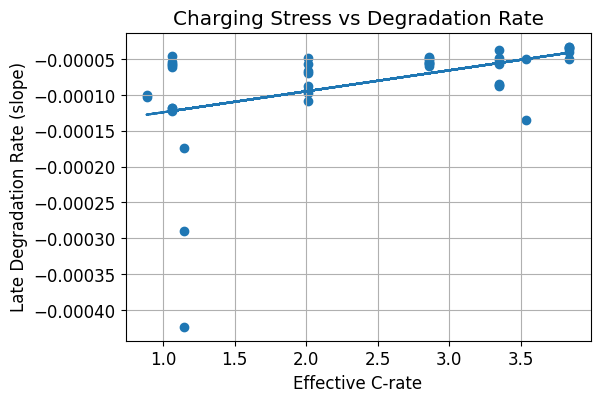

In [36]:
import matplotlib.pyplot as plt
import numpy as np

x = df_final["effective_C"]
y = df_final["slope_late"]

coef = np.polyfit(x, y, 1)
trend = np.poly1d(coef)

plt.figure(figsize=(6,4))
plt.scatter(x, y)
plt.plot(x, trend(x), linestyle="--")

plt.xlabel("Effective C-rate")
plt.ylabel("Late Degradation Rate (slope)")
plt.title("Charging Stress vs Degradation Rate")

plt.grid()
plt.show()

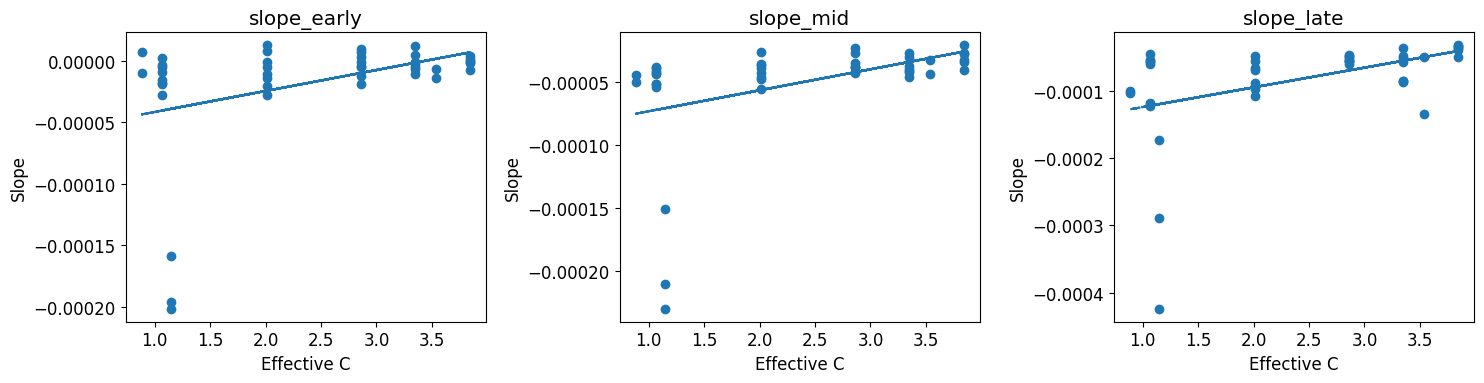

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

targets = ["slope_early", "slope_mid", "slope_late"]

for i, t in enumerate(targets):
    x = df_final["effective_C"]
    y = df_final[t]

    axes[i].scatter(x, y)

    coef = np.polyfit(x, y, 1)
    trend = np.poly1d(coef)
    axes[i].plot(x, trend(x), linestyle="--")

    axes[i].set_title(t)
    axes[i].set_xlabel("Effective C")
    axes[i].set_ylabel("Slope")

plt.tight_layout()
plt.show()

### 5. 상관관계 분석

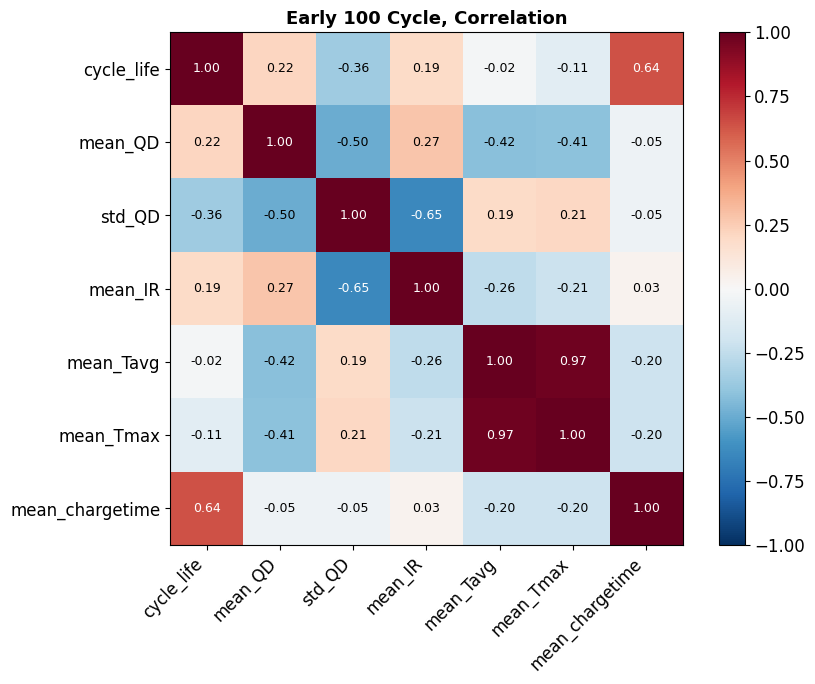


[cycle_life Corr Rank]
mean_chargetime    0.637
std_QD            -0.356
mean_QD            0.217
mean_IR            0.190
mean_Tmax         -0.106
mean_Tavg         -0.022
Name: cycle_life, dtype: float64


In [26]:
import matplotlib.colors as mcolors
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index(drop=True)

corr_matrix = early.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))